In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
from scipy.stats import norm

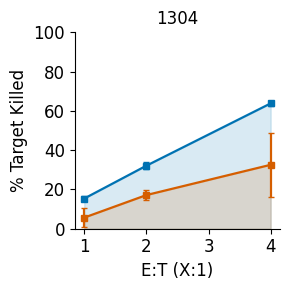

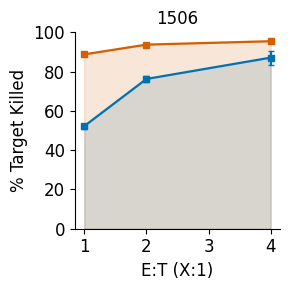

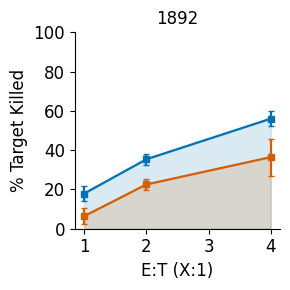

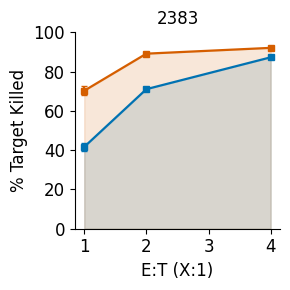

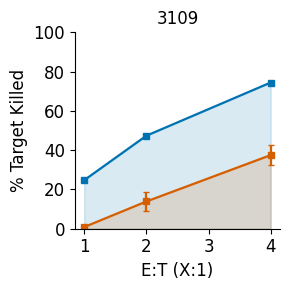

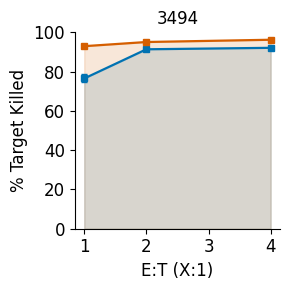

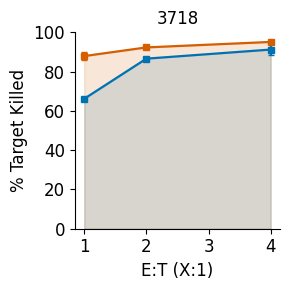

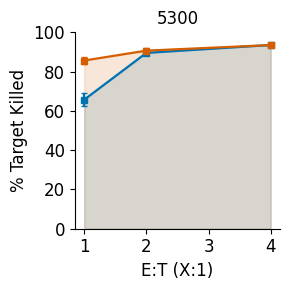

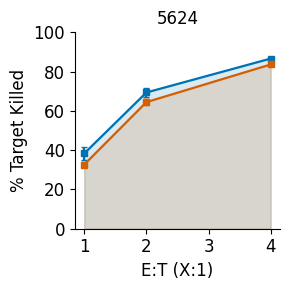

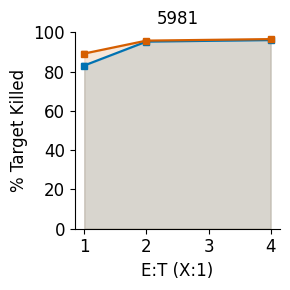

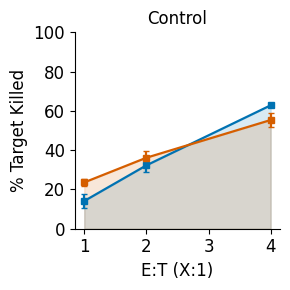

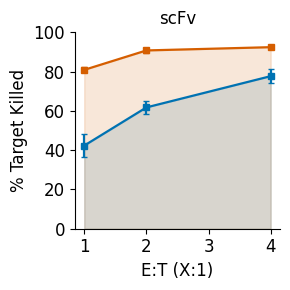

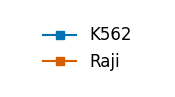

In [60]:
df = pd.read_csv("../data/good/leah_indiv_data/leah_cytotoxicity.csv")
cytotox_melted = df.melt(
    id_vars=["global_id", "E:T=(X:1)"],
    value_vars=[
        "K562-GFP-1", "K562-GFP-2", "K562-GFP-3",
        "Raji-GFP-1", "Raji-GFP-2", "Raji-GFP-3",
    ],
    var_name="Target_Replicate",
    value_name="Percent_Cytotoxicity",
)

cytotox_melted["Target"] = cytotox_melted["Target_Replicate"].str.extract(r"^(K562|Raji)")
cytotox_melted["E:T=(X:1)"] = pd.to_numeric(cytotox_melted["E:T=(X:1)"], errors="coerce")
cytotox_melted["Percent_Cytotoxicity"] = pd.to_numeric(cytotox_melted["Percent_Cytotoxicity"], errors="coerce")

colors = {"K562": "#0072B2", "Raji": "#D55E00"}

for uid, df_u in cytotox_melted.groupby("global_id"):
    fig, ax = plt.subplots(figsize=(3, 3))

    for target in ["K562", "Raji"]:
        df_t = df_u[df_u["Target"] == target]
        g = df_t.groupby("E:T=(X:1)")["Percent_Cytotoxicity"]
        x = np.array(sorted(g.groups.keys()), dtype=float)
        mean = g.mean().reindex(x).to_numpy()
        sd = g.std(ddof=1).reindex(x).to_numpy()

        ax.fill_between(x, 0, mean, color=colors[target], alpha=0.15)
        ax.errorbar(
            x, mean, yerr=sd,
            fmt="s-", markersize=4, linewidth=1.6,
            capsize=2, color=colors[target],
            label=f"{target}",
        )

    ax.set_title(str(uid))
    ax.set_xlabel("E:T (X:1)", fontsize=12)
    ax.set_ylabel("% Target Killed", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.set_ylim(0, 100)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"../results/top_ten_plots/cytotoxicity_{uid}.png", bbox_inches="tight", dpi=300)
    # plt.close()

# save a single legend
fig_legend, ax_legend = plt.subplots(figsize=(2, 1))
for target in ["K562", "Raji"]:
    ax_legend.plot([], [], color=colors[target], label=f"{target}", marker="s", linestyle="-")
legend = ax_legend.legend(frameon=False, fontsize=12, loc="center")
ax_legend.axis("off")
fig_legend.savefig("../results/top_ten_plots/cytotoxicity_legend.png", bbox_inches="tight", dpi=300)
# plt.close()

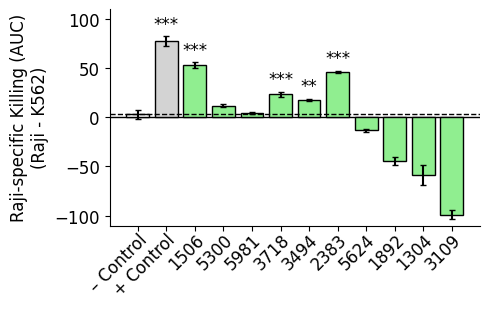

In [61]:
df = pd.read_csv("../data/good/leah_indiv_data/leah_cytotoxicity-agg.csv")
df["global_id"] = df["global_id"].astype(str)

desired_order = ["Control", "scFv", "1506", "5300", "5981", "3718", "3494", "2383", "5624", "1892", "1304", "3109"]
df = df.set_index("global_id").loc[desired_order].reset_index()
order = df["global_id"].tolist()
display_labels = ["– Control" if s == "Control" else "+ Control" if s == "scFv" else s for s in order]

y = df["diff-avg"].to_numpy()
yerr = df["diff-stderr"].to_numpy()

# colors
colors = np.array(["lightgreen"] * len(df), dtype=object)
colors[order.index("Control")] = "white"
colors[order.index("scFv")] = "lightgrey"

fig, ax = plt.subplots(figsize=(max(5, 0.35 * len(df)), 3.2))
x = np.arange(len(df))

ax.bar(x, y, color=colors, edgecolor="black")
ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="k", capsize=2, lw=1.5)

ax.set_xticks(x)
ax.set_xticklabels(display_labels, rotation=45, ha="right", va="top", fontsize=12, rotation_mode="anchor")
ax.tick_params(axis="x", pad=0)
ax.set_ylabel("Raji-specific Killing (AUC)\n(Raji - K562)", fontsize=12)
ax.set_ylim(-110, 110)
ax.axhline(0, color="0", linewidth=1, linestyle="-", zorder=0)
ax.tick_params(axis="y", which="major", labelsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# horizontal dotted line at the level of the negative control
ctrl_idx = order.index("Control")
ax.axhline(y[ctrl_idx], color="0", linewidth=1, linestyle="--", zorder=1)

# -----------------------------
# stats: directional one-sided test (must be greater than Control)
# -----------------------------
pvals = []
for i in range(len(y)):
    if i == ctrl_idx:
        pvals.append(1.0)
        continue

    se = np.sqrt(yerr[i]**2 + yerr[ctrl_idx]**2)
    z = (y[i] - y[ctrl_idx]) / se
    p = 1 - norm.cdf(z)  # one-sided: significant only if greater than control
    pvals.append(p)

pvals = np.array(pvals)


def bh_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    idx = np.argsort(pvals)
    ranks = np.arange(1, m + 1)

    q_sorted = pvals[idx] * m / ranks
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0, 1)

    q = np.empty(m, dtype=float)
    q[idx] = q_sorted
    return q

qvals = bh_adjust(pvals)

def stars(q):
    if q < 0.001:
        return "***"
    elif q < 0.01:
        return "**"
    elif q < 0.05:
        return "*"
    else:
        return ""

ymax = (y + yerr).max()
offset = 0.04 * ymax

for xi, yi, ei, qi in zip(x, y, yerr, qvals):
    s = stars(qi)
    if xi == ctrl_idx:
        continue
    ax.text(
        xi,
        yi + ei + offset,
        s,
        ha="center",
        va="bottom",
        fontsize=12,
    )

plt.tight_layout()
plt.savefig("../results/top_ten_plots/agg_specific_killing_topten.png", bbox_inches="tight", dpi=300)

# Bars show mean Raji-specific cytotoxicity AUC (Raji − K562) ± SE; significance stars denote BH-corrected one-sided z-tests (greater than negative control; ns, not significant; *, p < 0.05; **, p < 0.01; ***, p < 0.001).

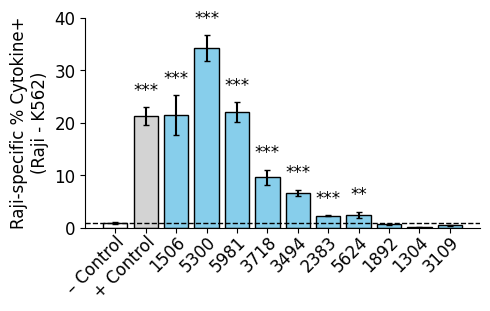

In [62]:
df = pd.read_csv("../data/good/leah_indiv_data/leah_cytokine.csv")
df["global_id"] = df["global_id"].astype(str)

desired_order = ["Control", "scFv", "1506", "5300", "5981", "3718", "3494", "2383", "5624", "1892", "1304", "3109"]
# desired_order = ["Control", "scFv", "1506", "5300", "5981", "3718", "3494", "2383", "5624", "1892", "1304", "3109"]
df = df.set_index("global_id").loc[desired_order].reset_index()
order = df["global_id"].tolist()
display_labels = ["– Control" if s == "Control" else "+ Control" if s == "scFv" else s for s in order]

no_cols = ["no_target-1", "no_target-2", "no_target-3"]
raji_cols = ["vs_Raji-1", "vs_Raji-2", "vs_Raji-3"]

no = df[no_cols].to_numpy(dtype=float)
raji = df[raji_cols].to_numpy(dtype=float)

no_mean = np.nanmean(no, axis=1)
raji_mean = np.nanmean(raji, axis=1)

no_sd = np.nanstd(no, axis=1, ddof=1)
raji_sd = np.nanstd(raji, axis=1, ddof=1)

n_no = np.sum(~np.isnan(no), axis=1)
n_raji = np.sum(~np.isnan(raji), axis=1)

y = raji_mean - no_mean
yerr = np.sqrt((raji_sd**2) / n_raji + (no_sd**2) / n_no)

# colors (same convention)
colors = np.array(["skyblue"] * len(df), dtype=object)
colors[order.index("Control")] = "white"
colors[order.index("scFv")] = "lightgrey"

fig, ax = plt.subplots(figsize=(max(5, 0.35 * len(df)), 3.2))
x = np.arange(len(df))

ax.bar(x, y, color=colors, edgecolor="black")
ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="k", capsize=2, lw=1.5)

ax.set_xticks(x)
ax.set_xticklabels(display_labels, rotation=45, ha="right", va="top", fontsize=12, rotation_mode="anchor")
ax.tick_params(axis="x", pad=0)

ax.set_ylabel("Raji-specific % Cytokine+\n(Raji - K562)", fontsize=12)
ax.set_ylim(0, 40)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", which="major", labelsize=12)

# horizontal dotted line at the level of the negative control
ctrl_idx = order.index("Control")
ax.axhline(y[ctrl_idx], color="0", linewidth=1, linestyle="--", zorder=1)

# ---- stats vs negative control (directional: must be greater) ----
pvals = []
for i in range(len(y)):
    if i == ctrl_idx:
        pvals.append(1.0)
        continue
    se = np.sqrt(yerr[i]**2 + yerr[ctrl_idx]**2)
    z = (y[i] - y[ctrl_idx]) / se
    p = 1 - norm.cdf(z)  # one-sided
    pvals.append(p)
pvals = np.asarray(pvals, dtype=float)

qvals = bh_adjust(pvals)

ymax = np.nanmax(y + yerr)
offset = 0.04 * ymax if ymax != 0 else 0.5

for xi, yi, ei, qi in zip(x, y, yerr, qvals):
    if xi == ctrl_idx:
        continue
    ax.text(xi, yi + ei + offset, stars(qi), ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.savefig("../results/top_ten_plots/agg_specific_cytokine.png", bbox_inches="tight", dpi=300)

# Bars show mean cytokine-positive % in the vs-Raji condition ± SE; significance stars denote BH-corrected one-sided z-tests (greater than negative control; ns, not significant; *, p < 0.05; **, p < 0.01; ***, p < 0.001).

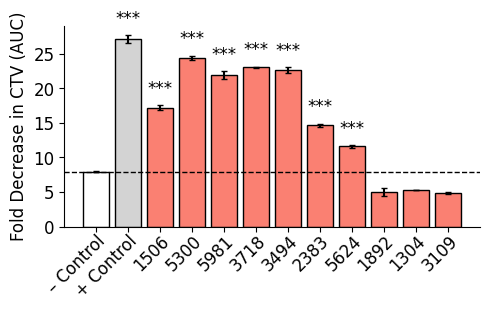

In [63]:
df = pd.read_csv("../data/good/leah_indiv_data/leah_ctv-exp-agg.csv")
df["global_id"] = df["global_id"].astype(str)

desired_order = ["Control", "scFv", "1506", "5300", "5981", "3718", "3494", "2383", "5624", "1892", "1304", "3109"]
df = df.set_index("global_id").loc[desired_order].reset_index()
order = df["global_id"].tolist()
display_labels = ["– Control" if s == "Control" else "+ Control" if s == "scFv" else s for s in order]

# -----------------------------
# Proliferation (CTV-MFI AUC)
# -----------------------------
mfi_cols = ["mfi-auc-1", "mfi-auc-2", "mfi-auc-3"]
y = df[mfi_cols].mean(axis=1).to_numpy()
sd = df[mfi_cols].std(axis=1, ddof=1).to_numpy()
se = sd / np.sqrt(len(mfi_cols))

colors = np.array(["salmon"] * len(df), dtype=object)
colors[order.index("Control")] = "white"
colors[order.index("scFv")] = "lightgrey"

fig, ax = plt.subplots(figsize=(max(5, 0.35 * len(df)), 3.2))
x = np.arange(len(df))

ax.bar(x, y, color=colors, edgecolor="black")
ax.errorbar(x, y, yerr=se, fmt="none", ecolor="k", capsize=2, lw=1.5)

ax.set_xticks(x)
ax.set_xticklabels(display_labels, rotation=45, ha="right", va="top", fontsize=12, rotation_mode="anchor")
ax.tick_params(axis="x", pad=0)
ax.set_ylabel("Fold Decrease in CTV (AUC)", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", which="major", labelsize=12)

# stats vs Control using replicate values (directional: must be greater)
ctrl_idx = order.index("Control")
ctrl_vals = df.loc[ctrl_idx, mfi_cols].to_numpy(dtype=float)

# horizontal dotted line at the level of the negative control
ctrl_y = float(np.mean(ctrl_vals))
ax.axhline(ctrl_y, color="0", linewidth=1, linestyle="--", zorder=1)

pvals = []
for i in range(len(df)):
    if i == ctrl_idx:
        pvals.append(1.0)
        continue
    vals = df.loc[i, mfi_cols].to_numpy(dtype=float)
    m1, m0 = float(np.mean(vals)), float(np.mean(ctrl_vals))
    s1, s0 = float(np.std(vals, ddof=1)), float(np.std(ctrl_vals, ddof=1))
    n1, n0 = len(vals), len(ctrl_vals)
    se_diff = np.sqrt((s1**2)/n1 + (s0**2)/n0)
    z = (m1 - m0) / se_diff
    pvals.append(1 - norm.cdf(z))  # one-sided

pvals = np.array(pvals)
qvals = bh_adjust(pvals)

ymax = (y + se).max()
offset = 0.04 * ymax

for xi, yi, ei, qi in zip(x, y, se, qvals):
    if xi == ctrl_idx:
        continue
    ax.text(xi, yi + ei + offset, stars(qi), ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.savefig("../results/top_ten_plots/agg_ctv_mfi.png", bbox_inches="tight", dpi=300)

# Bars show mean CTV MFI AUC ± SE; significance stars denote BH-corrected one-sided z-tests (greater than negative control; ns, not significant; *, p < 0.05; **, p < 0.01; ***, p < 0.001).

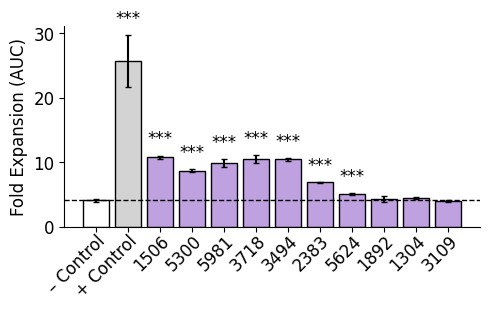

In [ ]:
df = pd.read_csv("../data/good/leah_indiv_data/leah_ctv-exp-agg.csv")
df["global_id"] = df["global_id"].astype(str)

desired_order = ["Control", "scFv", "1506", "5300", "5981", "3718", "3494", "2383", "5624", "1892", "1304", "3109"]
df = df.set_index("global_id").loc[desired_order].reset_index()
order = df["global_id"].tolist()
display_labels = ["– Control" if s == "Control" else "+ Control" if s == "scFv" else s for s in order]

# -----------------------------
# Expansion (Fold Expansion AUC)
# -----------------------------
exp_cols = ["foldexp-auc-1", "foldexp-auc-2", "foldexp-auc-3"]
y = df[exp_cols].mean(axis=1).to_numpy()
sd = df[exp_cols].std(axis=1, ddof=1).to_numpy()
se = sd / np.sqrt(len(exp_cols))

colors = np.array(["#BFA1DF"] * len(df), dtype=object)
colors[order.index("Control")] = "white"
colors[order.index("scFv")] = "lightgrey"

fig, ax = plt.subplots(figsize=(max(5, 0.35 * len(df)), 3.2))
x = np.arange(len(df))

ax.bar(x, y, color=colors, edgecolor="black")
ax.errorbar(x, y, yerr=se, fmt="none", ecolor="k", capsize=2, lw=1.5)

ax.set_xticks(x)
ax.set_xticklabels(display_labels, rotation=45, ha="right", va="top", fontsize=12, rotation_mode="anchor")
ax.tick_params(axis="x", pad=0)
ax.set_ylabel("Fold Expansion (AUC)", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", which="major", labelsize=12)

# stats vs Control using replicate values (directional: must be greater)
ctrl_idx = order.index("Control")
ctrl_vals = df.loc[ctrl_idx, exp_cols].to_numpy(dtype=float)

# horizontal dotted line at the level of the negative control
ctrl_y = float(np.mean(ctrl_vals))
ax.axhline(ctrl_y, color="0", linewidth=1, linestyle="--", zorder=1)

pvals = []
for i in range(len(df)):
    if i == ctrl_idx:
        pvals.append(1.0)
        continue
    vals = df.loc[i, exp_cols].to_numpy(dtype=float)
    m1, m0 = float(np.mean(vals)), float(np.mean(ctrl_vals))
    s1, s0 = float(np.std(vals, ddof=1)), float(np.std(ctrl_vals, ddof=1))
    n1, n0 = len(vals), len(ctrl_vals)
    se_diff = np.sqrt((s1**2)/n1 + (s0**2)/n0)
    z = (m1 - m0) / se_diff
    pvals.append(1 - norm.cdf(z))  # one-sided

pvals = np.array(pvals)
qvals = bh_adjust(pvals)

ymax = (y + se).max()
offset = 0.04 * ymax

for xi, yi, ei, qi in zip(x, y, se, qvals):
    if xi == ctrl_idx:
        continue
    ax.text(xi, yi + ei + offset, stars(qi), ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.savefig("../results/top_ten_plots/agg_foldexp.png", bbox_inches="tight", dpi=300)

# Bars show mean fold-expansion AUC ± SE; significance stars denote BH-corrected one-sided z-tests (greater than negative control; ns, not significant; *, p < 0.05; **, p < 0.01; ***, p < 0.001).

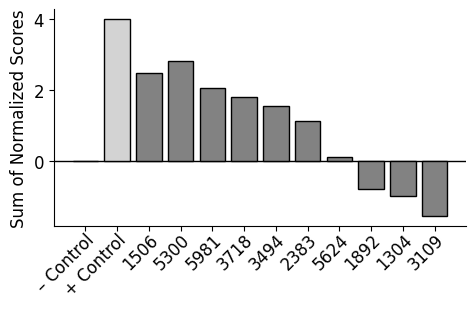

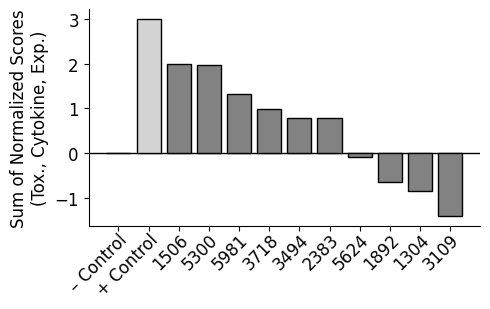

In [65]:
df = pd.read_csv("../data/good/leah_indiv_data/leah_final-score.csv")
df["global_id"] = df["global_id"].astype(str)

desired_order = ["Control", "scFv", "1506", "5300", "5981", "3718", "3494", "2383", "5624", "1892", "1304", "3109"]
df = df.set_index("global_id").loc[desired_order].reset_index()
order = df["global_id"].tolist()
display_labels = ["– Control" if s == "Control" else "+ Control" if s == "scFv" else s for s in order]

y = df["final_score_all"].to_numpy(dtype=float)

colors = np.array(["#828282"] * len(df), dtype=object)
colors[order.index("Control")] = "white"
colors[order.index("scFv")] = "lightgrey"

fig, ax = plt.subplots(figsize=(max(5, 0.35 * len(df)), 3.2))
x = np.arange(len(df))

ax.bar(x, y, color=colors, edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(display_labels, rotation=45, ha="right", va="top", fontsize=12, rotation_mode="anchor")
ax.axhline(0, color="0", linewidth=1, linestyle="-", zorder=0)
ax.tick_params(axis="x", pad=0)

ax.set_ylabel("Sum of Normalized Scores", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", which="major", labelsize=12)

plt.tight_layout()
plt.savefig("../results/top_ten_plots/final_score_four.png", bbox_inches="tight", dpi=300)


y = df["final_score"].to_numpy(dtype=float)

colors = np.array(["#828282"] * len(df), dtype=object)
colors[order.index("Control")] = "white"
colors[order.index("scFv")] = "lightgrey"

fig, ax = plt.subplots(figsize=(max(5, 0.35 * len(df)), 3.2))
x = np.arange(len(df))

ax.bar(x, y, color=colors, edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(display_labels, rotation=45, ha="right", va="top", fontsize=12, rotation_mode="anchor")
ax.axhline(0, color="0", linewidth=1, linestyle="-", zorder=0)
ax.tick_params(axis="x", pad=0)

ax.set_ylabel("Sum of Normalized Scores\n(Tox., Cytokine, Exp.)", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", which="major", labelsize=12)

plt.tight_layout()
plt.savefig("../results/top_ten_plots/final_score_three.png", bbox_inches="tight", dpi=300)

/stor/scratch/Ellington/archive/cwk687/home/micromamba/envs/dev/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_1300237/4109135259.py:22: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(3, 3))


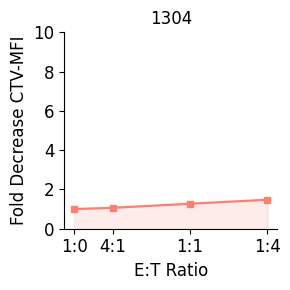

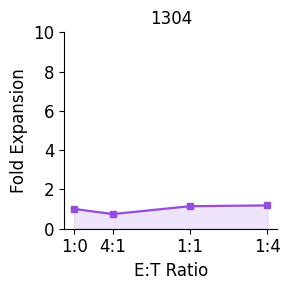

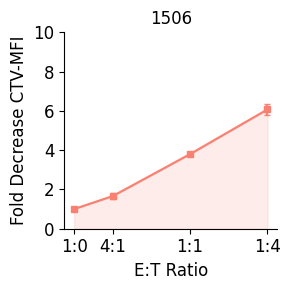

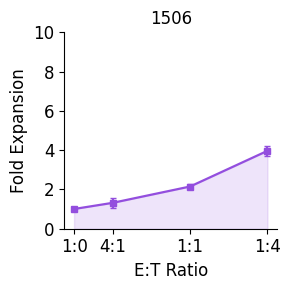

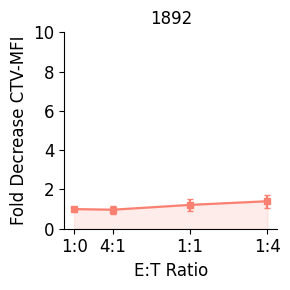

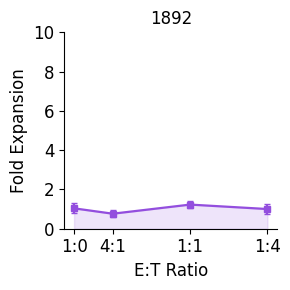

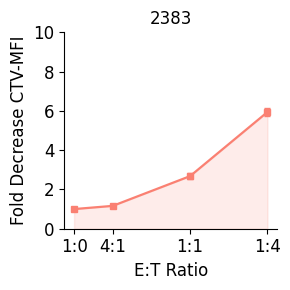

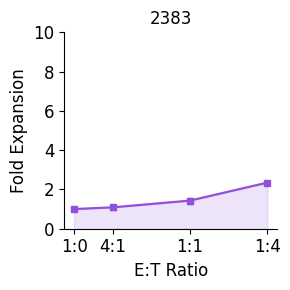

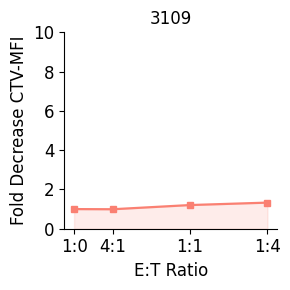

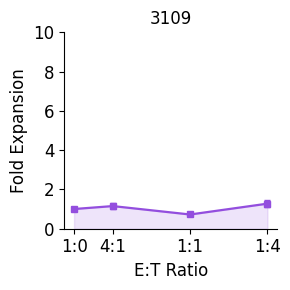

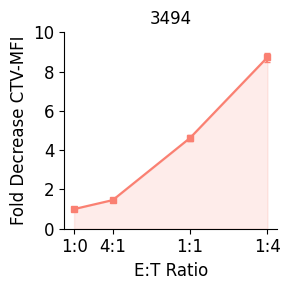

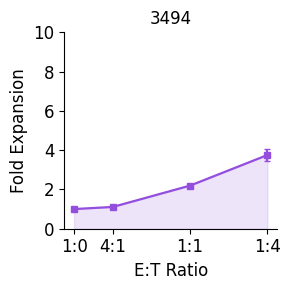

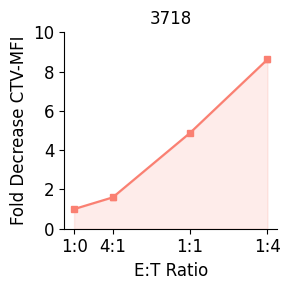

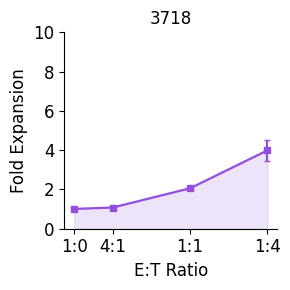

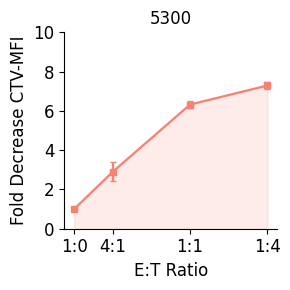

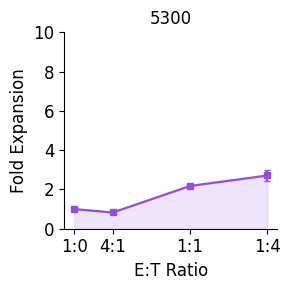

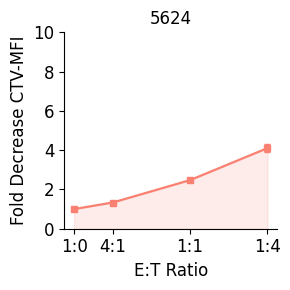

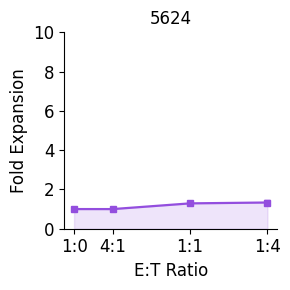

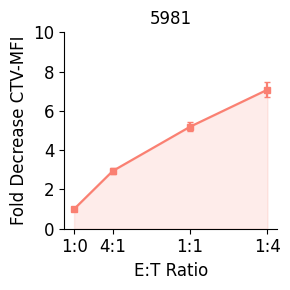

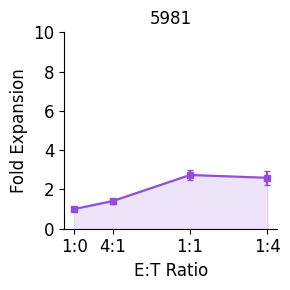

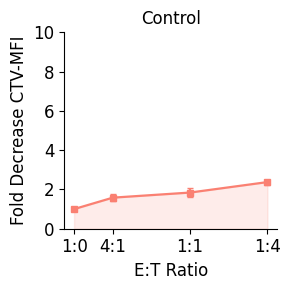

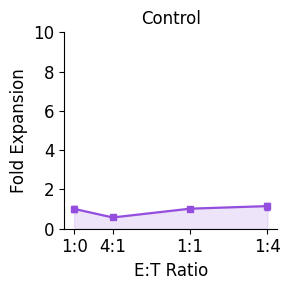

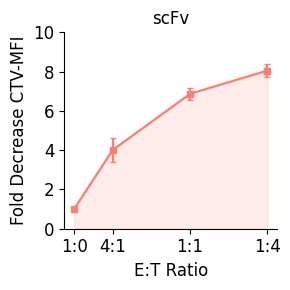

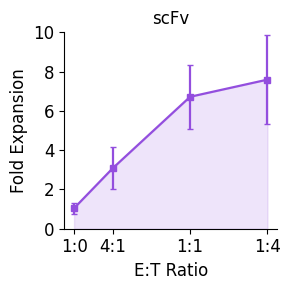

In [66]:
df = pd.read_csv("../data/good/leah_indiv_data/leah_ctv-exp-indiv.csv")

df["ratio"] = pd.to_numeric(df["ratio"], errors="coerce")

# log2 x-axis: treat 0 ("1:00") as a control point placed one step left of the smallest nonzero ratio
min_nonzero = df.loc[df["ratio"] > 0, "ratio"].min()
x0 = np.log2(min_nonzero) - 1  # puts control at -3 if min_nonzero=0.25
df["x_log2"] = np.where(df["ratio"] > 0, np.log2(df["ratio"]), x0)

colors = {"CTV": "salmon", "FoldExp": "#934ede"}

tick_order = ["1:00", "4:01", "1:01", "1:04"]
tick_labels = ["1:0", "4:1", "1:1", "1:4"]

tick_pos = []
for t in tick_order:
    r = df.loc[df["E:T=(X:1)"] == t, "ratio"].iloc[0]
    tick_pos.append(np.log2(r) if r > 0 else x0)

for uid, df_u in df.groupby("global_id"):
    # ---------- Plot 1: fold decrease in CTV-MFI (mfi-norm-*)
    fig, ax = plt.subplots(figsize=(3, 3))

    x = np.array(sorted(df_u["x_log2"].unique()), dtype=float)
    means, sds = [], []
    for xv in x:
        vals = df_u.loc[df_u["x_log2"] == xv, ["mfi-norm-1", "mfi-norm-2", "mfi-norm-3"]].to_numpy().ravel()
        vals = vals[~np.isnan(vals)]
        means.append(np.mean(vals))
        sds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0.0)

    means = np.array(means)
    sds = np.array(sds)

    ax.fill_between(x, 0, means, color=colors["CTV"], alpha=0.15)
    ax.errorbar(x, means, yerr=sds, fmt="s-", markersize=4, linewidth=1.6,
                capsize=2, color=colors["CTV"])

    ax.set_title(str(uid))
    ax.set_xlabel("E:T Ratio", fontsize=12)
    ax.set_ylabel("Fold Decrease CTV-MFI", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, fontsize=12)
    ax.tick_params(axis="x", rotation=0)

    # y lim 0 10
    ax.set_ylim(0, 10)

    plt.tight_layout()
    plt.savefig(f"../results/top_ten_plots/ctv_mfi_{uid}.png", bbox_inches="tight", dpi=300)
    # plt.close()

    # ---------- Plot 2: fold expansion (foldexp-*)
    fig, ax = plt.subplots(figsize=(3, 3))

    x = np.array(sorted(df_u["x_log2"].unique()), dtype=float)
    means, sds = [], []
    for xv in x:
        vals = df_u.loc[df_u["x_log2"] == xv, ["foldexp-1", "foldexp-2", "foldexp-3"]].to_numpy().ravel()
        vals = vals[~np.isnan(vals)]
        means.append(np.mean(vals))
        sds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0.0)

    means = np.array(means)
    sds = np.array(sds)

    ax.fill_between(x, 0, means, color=colors["FoldExp"], alpha=0.15)
    ax.errorbar(x, means, yerr=sds, fmt="s-", markersize=4, linewidth=1.6,
                capsize=2, color=colors["FoldExp"])

    ax.set_title(str(uid))
    ax.set_xlabel("E:T Ratio", fontsize=12)
    ax.set_ylabel("Fold Expansion", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, fontsize=12)
    ax.tick_params(axis="x", rotation=0)

    ax.set_ylim(0, 10)

    plt.tight_layout()
    plt.savefig(f"../results/top_ten_plots/foldexp_{uid}.png", bbox_inches="tight", dpi=300)
    # plt.close()